# **T07: Chi-Square Goodness-of-Fit Test**
## ADA2026 — Advanced Data Analytics (BI203)

---

## Task 1: Department Distribution

**Research Question:**
Are products uniformly distributed across all departments?

**Hypotheses:**
- H₀: Product departments are uniformly distributed
  (each department has an equal proportion of products)
- Hₐ: Product departments are not uniformly distributed

**Significance Level:** α = 0.05

**Assumptions:**
1. Categories (departments) are mutually exclusive
2. Observations are independent
3. Each expected frequency is at least 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

interim_path = '/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/'
products = pd.read_csv(interim_path + 'products_interim.csv')

print("Data loaded successfully ✅")
print(f"Products shape: {products.shape}")

Mounted at /content/drive
Data loaded successfully ✅
Products shape: (49688, 4)


In [2]:
# Compute observed department frequencies
observed = products['department_id'].value_counts().sort_index()
n = observed.sum()
k = len(observed)

# Expected frequencies (uniform distribution)
expected = [n / k] * k

print(f"Total Products (n): {n:,}")
print(f"Number of Departments (k): {k}")
print(f"Expected Frequency per Department: {n/k:.2f}")
print(f"\nObserved Frequencies:")
print(observed)

Total Products (n): 49,688
Number of Departments (k): 21
Expected Frequency per Department: 2366.10

Observed Frequencies:
department_id
1     4007
2      548
3     1516
4     1684
5     1054
6     1139
7     4365
8      972
9     1858
10      38
11    6563
12     907
13    5371
14    1115
15    2092
16    3449
17    3085
18    1081
19    6264
20    1322
21    1258
Name: count, dtype: int64


In [3]:
# Run Chi-Square GOF test
chi2_stat, p_value = chisquare(observed, f_exp=expected)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value}")
print(f"Degrees of Freedom: {k-1}")
print(f"\nDecision at α = 0.05:")
if p_value < 0.05:
    print("Reject H₀ ✅ — departments are NOT uniformly distributed")
else:
    print("Fail to Reject H₀ — departments are uniformly distributed")

Chi-Square Statistic: 30977.6448
p-value: 0.0
Degrees of Freedom: 20

Decision at α = 0.05:
Reject H₀ ✅ — departments are NOT uniformly distributed


In [4]:
# Manual chi-square calculation
expected_array = np.array(expected)
observed_array = np.array(observed)

manual_chi2 = np.sum((observed_array - expected_array)**2 / expected_array)
print(f"Manual Chi-Square Statistic: {manual_chi2:.4f}")

# Contributions per department
contributions = (observed_array - expected_array)**2 / expected_array
contrib_df = pd.DataFrame({
    'department_id': observed.index,
    'observed': observed_array,
    'expected': expected_array.round(2),
    'contribution': contributions.round(4)
}).sort_values('contribution', ascending=False)

print("\nTop departments contributing most to χ²:")
print(contrib_df.head(5))

Manual Chi-Square Statistic: 30977.6448

Top departments contributing most to χ²:
    department_id  observed  expected  contribution
10             11      6563    2366.1     7444.3367
18             19      6264    2366.1     6421.4074
12             13      5371    2366.1     3816.1831
9              10        38    2366.1     2290.7055
6               7      4365    2366.1     1688.6980


## **Task 1: Interpretation**

**Chi-Square Test Results:**
| Measure | Value |
|---------|-------|
| Chi-Square Statistic (χ²) | 30,977.6448 |
| Degrees of Freedom | 20 |
| p-value | 0.0 |
| Decision | Reject H₀ |

**Manual Verification:**
The manually computed χ² statistic of **30,977.6448** matches
the Python output exactly, confirming the calculation is correct.

**Statistical Conclusion:**
At α = 0.05, we reject H₀. There is overwhelming evidence that
products are **not uniformly distributed** across departments.

**Top Contributing Departments:**
| Department ID | Observed | Expected | Contribution |
|---------------|----------|----------|--------------|
| 11 | 6,563 | 2,366.10 | 7,444.34 |
| 19 | 6,264 | 2,366.10 | 6,421.41 |
| 13 | 5,371 | 2,366.10 | 3,816.18 |
| 10 | 38 | 2,366.10 | 2,290.71 |
| 7 | 4,365 | 2,366.10 | 1,688.70 |

**Business Interpretation:**
- Departments 11, 19 and 13 have far more products than expected,
  suggesting these are the most diverse and well stocked departments
- Department 10 has only **38 products** compared to the expected
  2,366 — it is severely underrepresented
- Instacart should review underrepresented departments for
  potential expansion opportunities to improve product variety

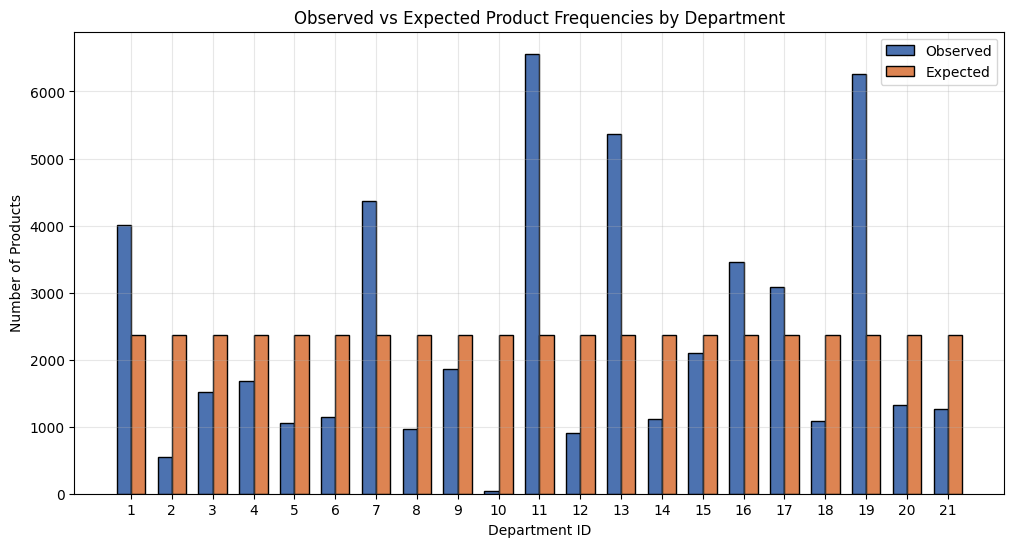

Figure saved successfully ✅


In [5]:
plt.figure(figsize=(12, 6))
x = np.arange(k)
width = 0.35

plt.bar(x - width/2, observed_array, width, label='Observed',
        color='#4c72b0', edgecolor='black')
plt.bar(x + width/2, expected_array, width, label='Expected',
        color='#dd8452', edgecolor='black')

plt.xlabel("Department ID")
plt.ylabel("Number of Products")
plt.title("Observed vs Expected Product Frequencies by Department")
plt.xticks(x, observed.index)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/Outputs/figures/dept_distribution.png",
            bbox_inches='tight')
plt.show()
print("Figure saved successfully ✅")

### **Bar Chart Interpretation**

The chart clearly shows that product frequencies vary widely
across departments:
- **Departments 11, 19 and 13** have significantly more products
  than the expected uniform frequency of 2,366
- **Department 10** is barely visible — with only 38 products it
  is the most underrepresented department
- The orange expected bars are all at the same height (2,366),
  while the blue observed bars vary dramatically
- This visual confirms our chi-square result that departments
  are **far from uniformly distributed**

## **Task 2: Hour-of-Day Distribution**

**Research Question:**
Are orders uniformly distributed across all 24 hours of the day?

**Hypotheses:**
- H₀: Orders are uniformly distributed across all 24 hours
  (each hour has an equal proportion of orders, E = n/24)
- Hₐ: Orders are not uniformly distributed across 24 hours

**Significance Level:** α = 0.05

**Assumptions:**
1. Categories (hours) are mutually exclusive
2. Observations are independent
3. Each expected frequency is at least 5

In [6]:
orders = pd.read_csv(interim_path + 'orders_interim.csv')

# Observed frequencies by hour
observed_hour = orders['order_hour_of_day'].value_counts().sort_index()
n_hour = observed_hour.sum()
k_hour = len(observed_hour)

# Expected frequencies
expected_hour = [n_hour / k_hour] * k_hour

print(f"Total Orders (n): {n_hour:,}")
print(f"Number of Hours (k): {k_hour}")
print(f"Expected Frequency per Hour: {n_hour/k_hour:.2f}")
print(f"\nObserved Frequencies:")
print(observed_hour)

Total Orders (n): 3,421,083
Number of Hours (k): 24
Expected Frequency per Hour: 142545.12

Observed Frequencies:
order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
Name: count, dtype: int64


In [7]:
# Run Chi-Square GOF test
chi2_stat_hour, p_value_hour = chisquare(observed_hour, f_exp=expected_hour)

print(f"Chi-Square Statistic: {chi2_stat_hour:.4f}")
print(f"p-value: {p_value_hour}")
print(f"Degrees of Freedom: {k_hour - 1}")
print(f"\nDecision at α = 0.05:")
if p_value_hour < 0.05:
    print("Reject H₀ ✅ — orders are NOT uniformly distributed across hours")
else:
    print("Fail to Reject H₀ — orders are uniformly distributed across hours")

# Manual verification
observed_hour_array = np.array(observed_hour)
expected_hour_array = np.array(expected_hour)
manual_chi2_hour = np.sum((observed_hour_array - expected_hour_array)**2 / expected_hour_array)
print(f"\nManual Chi-Square Statistic: {manual_chi2_hour:.4f}")

# Top contributing hours
contributions_hour = (observed_hour_array - expected_hour_array)**2 / expected_hour_array
contrib_hour_df = pd.DataFrame({
    'hour': observed_hour.index,
    'observed': observed_hour_array,
    'expected': expected_hour_array.round(2),
    'contribution': contributions_hour.round(4)
}).sort_values('contribution', ascending=False)

print("\nTop hours contributing most to χ²:")
print(contrib_hour_df.head(5))

Chi-Square Statistic: 2101573.3525
p-value: 0.0
Degrees of Freedom: 23

Decision at α = 0.05:
Reject H₀ ✅ — orders are NOT uniformly distributed across hours

Manual Chi-Square Statistic: 2101573.3525

Top hours contributing most to χ²:
    hour  observed   expected  contribution
10    10    288418  142545.12   149278.3121
11    11    284728  142545.12   141821.5456
15    15    283639  142545.12   139657.4002
14    14    283042  142545.12   138478.0566
3      3      5474  142545.12   131807.3369


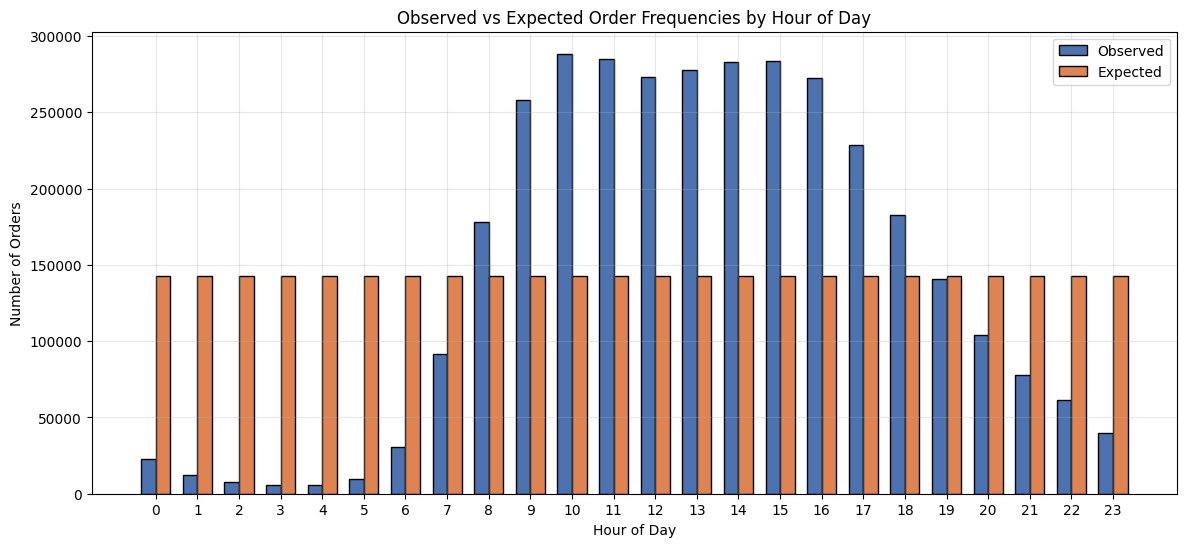

Figure saved successfully ✅


In [8]:
plt.figure(figsize=(14, 6))
x = np.arange(k_hour)
width = 0.35

plt.bar(x - width/2, observed_hour_array, width, label='Observed',
        color='#4c72b0', edgecolor='black')
plt.bar(x + width/2, expected_hour_array, width, label='Expected',
        color='#dd8452', edgecolor='black')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Observed vs Expected Order Frequencies by Hour of Day")
plt.xticks(x, observed_hour.index)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/Outputs/figures/hour_distribution.png",
            bbox_inches='tight')
plt.show()
print("Figure saved successfully ✅")

### **Task 2: Interpretation**

**Chi-Square Test Results:**
| Measure | Value |
|---------|-------|
| Chi-Square Statistic (χ²) | 2,101,573.3525 |
| Degrees of Freedom | 23 |
| p-value | 0.0 |
| Decision | Reject H₀ |

**Manual Verification:**
The manually computed χ² of **2,101,573.3525** matches the
Python output exactly ✅

**Statistical Conclusion:**
At α = 0.05 we reject H₀. There is overwhelming evidence that
orders are **not uniformly distributed** across the 24 hours
of the day.

**Top Contributing Hours:**
| Hour | Observed | Expected | Contribution |
|------|----------|----------|--------------|
| 10 AM | 288,418 | 142,545 | 149,278.31 |
| 11 AM | 284,728 | 142,545 | 141,821.55 |
| 3 PM | 283,639 | 142,545 | 139,657.40 |
| 2 PM | 283,042 | 142,545 | 138,478.06 |
| 3 AM | 5,474 | 142,545 | 131,807.34 |

**Business Interpretation:**
- Peak ordering hours are between **10 AM and 3 PM**, with over
  280,000 orders per hour during this period
- The lowest activity occurs between **12 AM and 6 AM**,
  with as few as 5,474 orders at 3 AM
- Instacart should **concentrate staffing, delivery drivers and
  inventory replenishment** during peak hours (10 AM — 3 PM)
- Late night promotions could be used to **shift some demand**
  to off-peak hours to balance workload

## **Task 3: Reorder Flag Distribution**

**Research Question:**
Do reorder vs first-time orders follow a 50-50 distribution?

**Hypotheses:**
- H₀: p = 0.5 (reorder and first-time orders are equally likely)
- Hₐ: p ≠ 0.5 (reorder and first-time orders are not equally likely)

**Significance Level:** α = 0.05

**Assumptions:**
1. Categories (reordered vs first-time) are mutually exclusive
2. Observations are independent
3. Each expected frequency is at least 5

In [9]:
order_products = pd.read_csv(interim_path + 'order_products_interim.csv')

# Observed frequencies
observed_reorder = order_products['reordered'].value_counts().sort_index()
n_reorder = observed_reorder.sum()

# Expected frequencies (50-50)
expected_reorder = [n_reorder * 0.5, n_reorder * 0.5]

print(f"Total Order Products (n): {n_reorder:,}")
print(f"Expected Frequency each: {n_reorder * 0.5:,.2f}")
print(f"\nObserved Frequencies:")
print(observed_reorder)

Total Order Products (n): 32,434,489
Expected Frequency each: 16,217,244.50

Observed Frequencies:
reordered
0    13307953
1    19126536
Name: count, dtype: int64


In [10]:
# Run Chi-Square GOF test
chi2_stat_reorder, p_value_reorder = chisquare(observed_reorder,
                                                f_exp=expected_reorder)

print(f"Chi-Square Statistic: {chi2_stat_reorder:.4f}")
print(f"p-value: {p_value_reorder}")
print(f"Degrees of Freedom: {len(observed_reorder) - 1}")
print(f"\nDecision at α = 0.05:")
if p_value_reorder < 0.05:
    print("Reject H₀ ✅ — reorder distribution is NOT 50-50")
else:
    print("Fail to Reject H₀ — reorder distribution follows 50-50")

# Manual verification
observed_reorder_array = np.array(observed_reorder)
expected_reorder_array = np.array(expected_reorder)
manual_chi2_reorder = np.sum((observed_reorder_array - expected_reorder_array)**2 /
                              expected_reorder_array)
print(f"\nManual Chi-Square Statistic: {manual_chi2_reorder:.4f}")

# Contributions
contributions_reorder = (observed_reorder_array - expected_reorder_array)**2 / expected_reorder_array
print(f"\nContributions:")
print(f"First-time orders (0): {contributions_reorder[0]:.4f}")
print(f"Reorders (1): {contributions_reorder[1]:.4f}")

Chi-Square Statistic: 1043824.3108
p-value: 0.0
Degrees of Freedom: 1

Decision at α = 0.05:
Reject H₀ ✅ — reorder distribution is NOT 50-50

Manual Chi-Square Statistic: 1043824.3108

Contributions:
First-time orders (0): 521912.1554
Reorders (1): 521912.1554


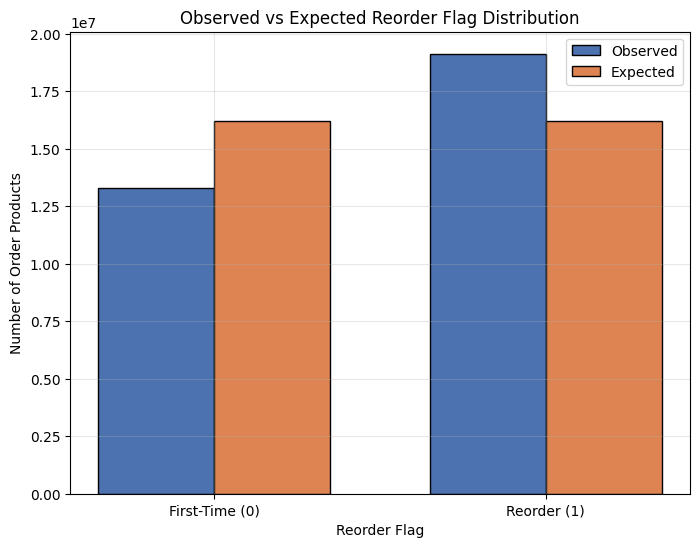

Figure saved successfully ✅


In [ ]:
plt.figure(figsize=(8, 6))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, observed_reorder_array, width, label='Observed',
        color='#4c72b0', edgecolor='black')
plt.bar(x + width/2, expected_reorder_array, width, label='Expected',
        color='#dd8452', edgecolor='black')

plt.xlabel("Reorder Flag")
plt.ylabel("Number of Order Products")
plt.title("Observed vs Expected Reorder Flag Distribution")
plt.xticks(x, ['First-Time (0)', 'Reorder (1)'])
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/Outputs/figures/reorder_distribution.png",
            bbox_inches='tight')
plt.show()
print("Figure saved successfully ✅")

## **Task 3: Interpretation**

**Chi-Square Test Results:**
| Measure | Value |
|---------|-------|
| Chi-Square Statistic (χ²) | 1,043,824.3108 |
| Degrees of Freedom | 1 |
| p-value | 0.0 |
| Decision | Reject H₀ |

**Manual Verification:**
The manually computed χ² of **1,043,824.3108** matches the
Python output exactly ✅

**Observed vs Expected:**
| Category | Observed | Expected |
|----------|----------|----------|
| First-time (0) | 13,307,953 | 16,217,244.50 |
| Reorder (1) | 19,126,536 | 16,217,244.50 |

**Statistical Conclusion:**
At α = 0.05 we reject H₀. There is overwhelming evidence that
reorder and first-time orders do **not** follow a 50-50 distribution.

**Business Interpretation:**
- **59%** of all order products are reorders while only **41%**
  are first-time purchases
- This shows that Instacart customers are highly habitual —
  they tend to repurchase familiar products rather than
  exploring new ones
- Instacart could leverage this by improving **personalised
  recommendations** to encourage customers to discover
  new products
- The high reorder rate also suggests strong **customer loyalty**
  which is valuable for retention strategies